PCA

   Principal Component Most Influential Feature  Explained Variance Ratio
0                  PC1                mfcc2_var                  0.235683
1                  PC2             rolloff_mean                  0.166545
2                  PC3              mfcc10_mean                  0.105655
3                  PC4              mfcc17_mean                  0.074709
4                  PC5              mfcc16_mean                  0.045014
5                  PC6              harmony_var                  0.033777
6                  PC7             harmony_mean                  0.029439
7                  PC8            perceptr_mean                  0.025616
8                  PC9             harmony_mean                  0.023732
9                 PC10                   length                  0.019634
10                PC11                    tempo                  0.017729
11                PC12                    tempo                  0.016020
12                PC13                

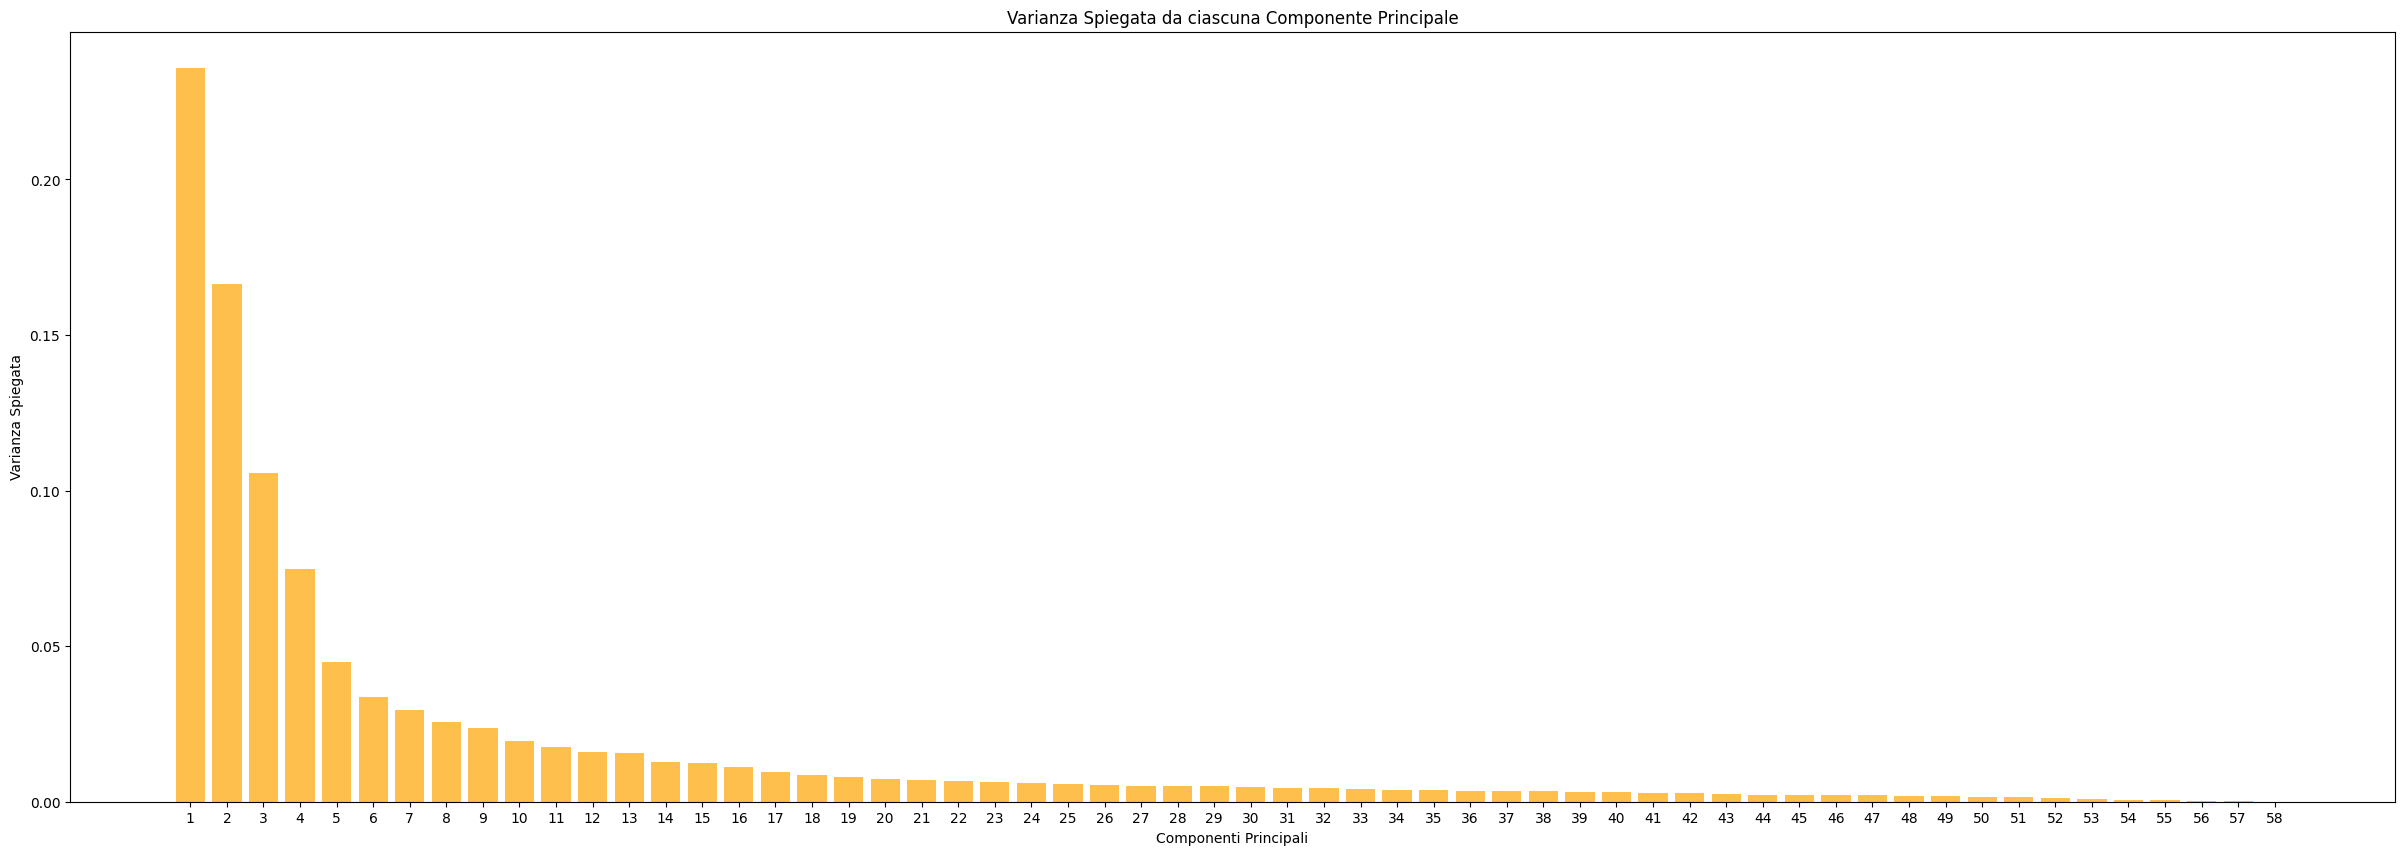

In [4]:
# Rimuovo le colonne non numeriche
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import StandardScaler

music_data_30sec = pd.read_csv('Data/features_30_sec.csv')

X = music_data_30sec.drop(columns=['label', 'filename', 'length'])  # Rimuovo le colonne non numeriche
feature_names = X.columns  # Salva i nomi delle colonne originali

# Normalizzo i dati
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Applico PCA
pca = PCA()  # Per calcolare tutte le componenti principali
X_pca = pca.fit_transform(X_scaled)

# Identifico le feature più rappresentative per ogni componente principale
pc_feature_contributions = pd.DataFrame(pca.components_, columns=feature_names, index=[f'PC{i+1}' for i in range(len(pca.components_))])

# Trovo la feature con il valore assoluto più alto per ogni PC
most_influential_features = pc_feature_contributions.abs().idxmax(axis=1)
explained_variances = pca.explained_variance_ratio_

# Combino i risultati in un DataFrame
pc_summary = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(pca.components_))],
    'Most Influential Feature': most_influential_features.values,
    'Explained Variance Ratio': explained_variances
})

print(pc_summary)

# Grafico della varianza spiegata da ciascuna componente principale
plt.figure(figsize=(30, 10))
plt.bar(range(1, len(explained_variances) + 1), explained_variances, alpha=0.7, color='orange')
plt.xlabel('Componenti Principali')
plt.ylabel('Varianza Spiegata')
plt.title('Varianza Spiegata da ciascuna Componente Principale')
plt.xticks(range(1, len(explained_variances) + 1))  # Aggiungi i numeri delle componenti sull'asse x
plt.show()